# Student Depression Analysis and Machine Learning

## Project Overview
This project explores a student depression dataset to better understand the factors associated with students' mental well-being. The notebook includes data preprocessing, exploratory data analysis (EDA), feature analysis, and visualization to identify patterns that may contribute to depression. The insights from this analysis can support the development of future machine learning models for early risk assessment.

### Objectives
- Explore and understand the student depression dataset.
- Clean and preprocess the data.
- Perform exploratory data analysis and visualization.
- Identify important factors associated with depression.
- Prepare the dataset for future machine learning models.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hopesb/student-depression-dataset/Student Depression Dataset.csv


In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/kaggle/input/datasets/hopesb/student-depression-dataset/Student Depression Dataset.csv")
print(df.head())
df.shape

   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours        Healthy       BA   
3          7-8

(27901, 18)

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149421,40641.175216,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822300,4.905687,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141214,1.381465,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000430,0.043992,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656104,1.470707,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.943837,1.361148,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.000681,0.044394,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.156984,3.707642,0.0,4.00,8.00,10.00,12.0
Financial Stress,27898.0,3.139867,1.437347,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585499,0.492645,0.0,0.00,1.00,1.00,1.0


In [4]:
print(df.groupby('Depression').mean(numeric_only=True))

                      id        Age  Academic Pressure  Work Pressure  \
Depression                                                              
0           70397.561089  27.142412           2.361608       0.000605   
1           70473.715536  24.887733           3.693132       0.000306   

                CGPA  Study Satisfaction  Job Satisfaction  Work/Study Hours  \
Depression                                                                     
0           7.617282            3.215564          0.000865          6.237959   
1           7.683588            2.751469          0.000551          7.807603   

            Financial Stress  
Depression                    
0                   2.518724  
1                   3.579553  


In [5]:
print(df['Depression'].value_counts())

Depression
1    16336
0    11565
Name: count, dtype: int64


In [6]:
print(df.corr(numeric_only=True))

                          id       Age  Academic Pressure  Work Pressure  \
id                  1.000000  0.003783           0.005172       0.001261   
Age                 0.003783  1.000000          -0.075803       0.002015   
Academic Pressure   0.005172 -0.075803           1.000000      -0.022231   
Work Pressure       0.001261  0.002015          -0.022231       1.000000   
CGPA               -0.012324  0.005056          -0.022239      -0.050896   
Study Satisfaction  0.007794  0.009235          -0.110988      -0.021145   
Job Satisfaction    0.001931 -0.000432          -0.024945       0.770652   
Work/Study Hours   -0.004466 -0.032928           0.095970      -0.005468   
Financial Stress    0.000783 -0.095026           0.151706       0.001883   
Depression          0.000923 -0.226422           0.474835      -0.003351   

                        CGPA  Study Satisfaction  Job Satisfaction  \
id                 -0.012324            0.007794          0.001931   
Age                 0.0

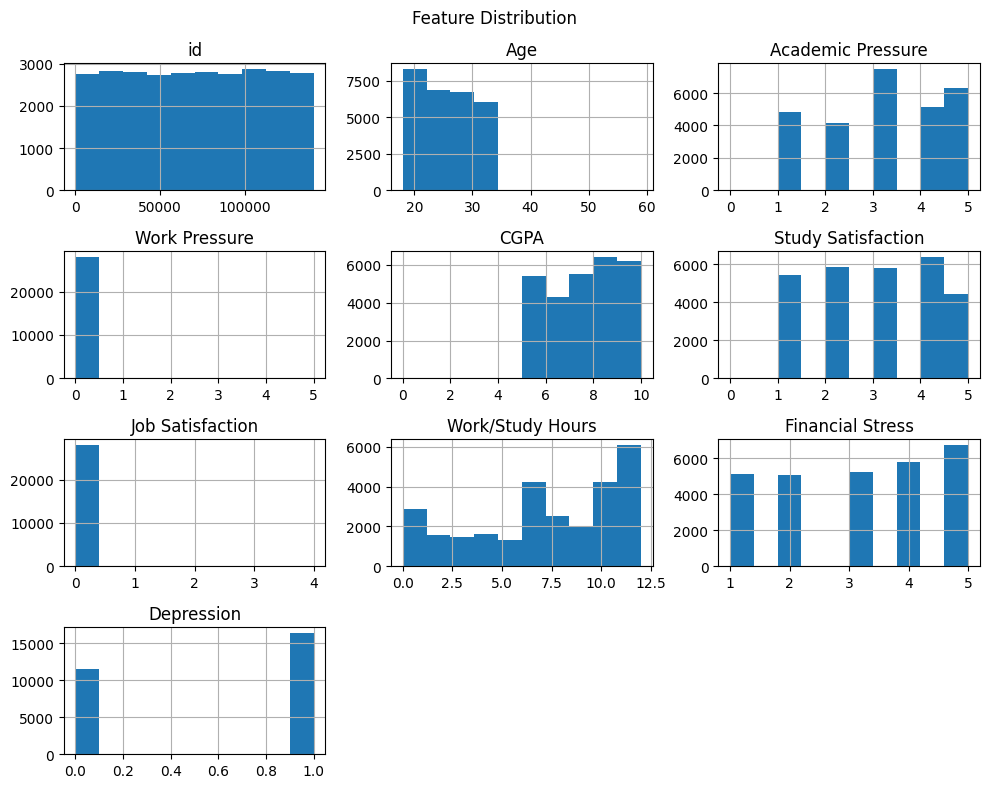

In [8]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.tight_layout()
plt.show()


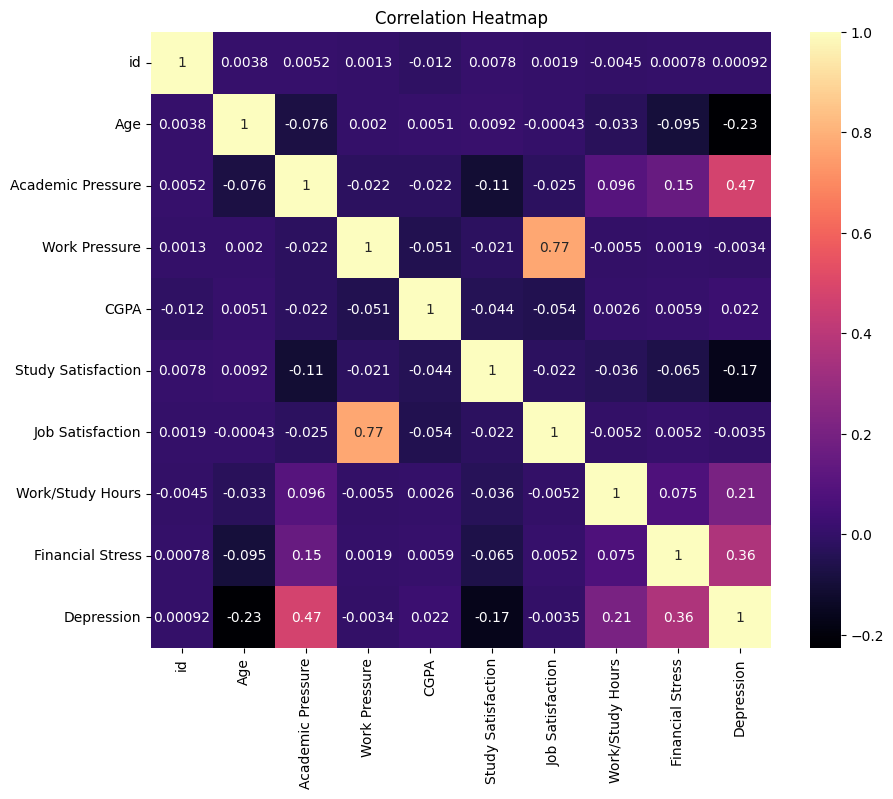

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='magma')
plt.title("Correlation Heatmap")
plt.show()

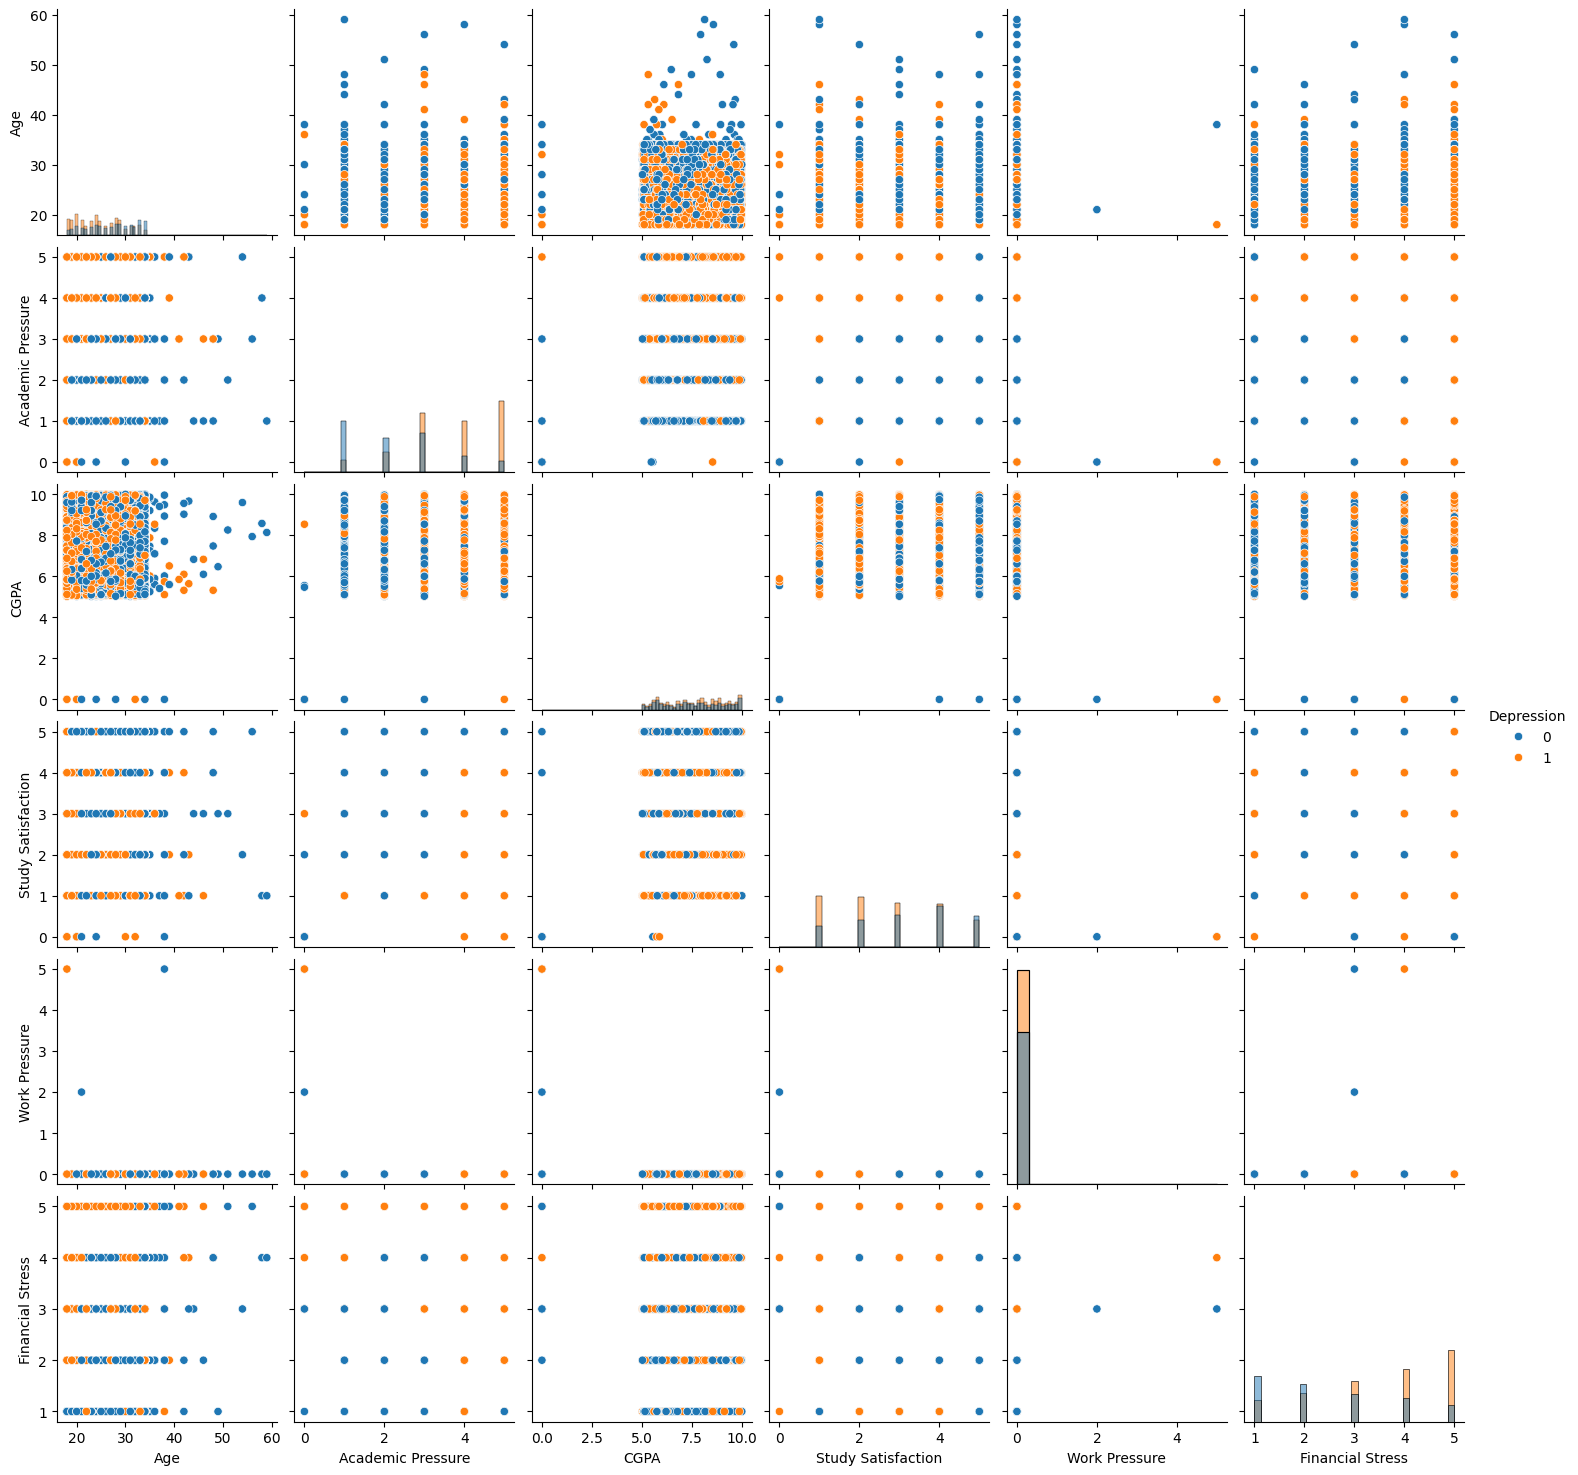

In [10]:
selected_cols = [
    col for col in [
        'Age',
        'Academic Pressure',
        'CGPA',
        'Study Satisfaction',
        'Work Pressure',
        'Financial Stress',
        'Depression'
    ]
    if col in df.columns
]

sns.pairplot(
    df[selected_cols],
    hue='Depression',
    diag_kind='hist'  
)
plt.show()

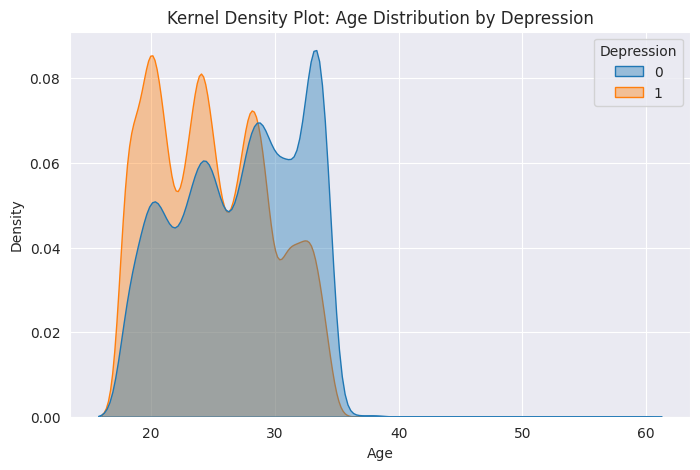

In [11]:
#kernel plot
sns.set_style("darkgrid")
plt.figure(figsize=(8, 5))
sns.kdeplot(
        data=df,
        x='Age',
        hue='Depression',
        fill=True,
        common_norm=False,
        alpha=0.4
    )
plt.title('Kernel Density Plot: Age Distribution by Depression')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()


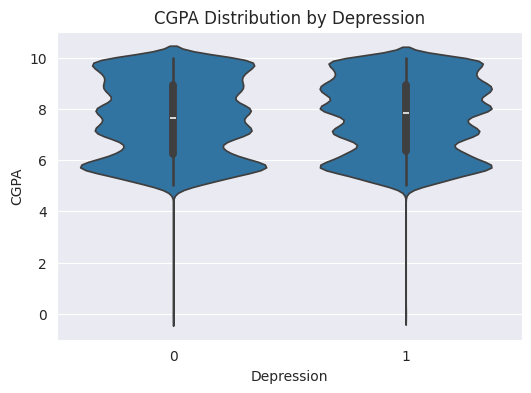

In [12]:
plt.figure(figsize=(6, 4))
sns.violinplot(x='Depression', y='CGPA', data=df)
plt.title('CGPA Distribution by Depression')
plt.xlabel('Depression')
plt.ylabel('CGPA')
plt.show()

## Conclusion

This project provided practical experience in analyzing a real-world mental health dataset through preprocessing, exploratory data analysis, and visualization. It improved my understanding of how demographic, academic, and lifestyle factors relate to student depression. As future work, I plan to build and compare machine learning models for depression prediction while emphasizing responsible data use, model reliability, and ethical AI practices.
